# HumanForYou - Modélisation

L'objectif, c'est de prédire si un employé va partir (Attrition = 1). C'est un problème de classification binaire, pas de régression (on ne prédit pas une valeur continue) ni de clustering (on a des étiquettes connues).

On compare plusieurs algorithmes, mais en faisant attention à ce que les comparaisons aient du sens. On procède en deux temps :

**Partie 1** : on compare 4 familles d'algorithmes vraiment différentes - régression logistique, arbre de décision, k-NN, SVM. Ces 4-là représentent des approches fondamentalement différentes, c'est pertinent de les mettre face à face.

**Partie 2** : on montre la progression arbre de décision vers Random Forest. Le RF n'est pas un concurrent du DT, c'est son évolution directe (un ensemble de DT). On le traite séparément pour que ce soit logique.

## Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics          import (classification_report, roc_auc_score,
                                      f1_score, ConfusionMatrixDisplay, roc_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROC = "../data/processed/"

## 1. Chargement des données

In [11]:
# On charge les données encodées mais NON normalisées
# Le scaler sera ajusté uniquement sur X_train ci-dessous
df = pd.read_csv(PROC + "dataset_encoded.csv")

X = df.drop(columns=["Attrition", "EmployeeID"])
y = df["Attrition"]

print(f"X : {X.shape}")
print(f"y : {y.value_counts().to_dict()}")

X : (4410, 43)
y : {0: 3699, 1: 711}


> **Prevention du data leakage :** les donnees chargees ici sont non normalisees (`dataset_encoded.csv`). Le `StandardScaler` est ajuste uniquement sur `X_train` et applique sur `X_test` via `.transform()` sans re-fit. Cela garantit que les statistiques de normalisation (moyenne, ecart-type) ne sont jamais calculees a partir des donnees de test.

## 2. Split train / test

80 % pour l'entraînement, 20 % pour le test. Le `stratify=y` garantit qu'on garde la même proportion de partants dans les deux parties, indispensable vu le déséquilibre.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling ajuste uniquement sur X_train (bonne pratique anti data leakage)
cols_norm = joblib.load("../models/cols_norm.pkl")
cols_to_scale = [c for c in cols_norm if c in X_train.columns]

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(f"Train : {X_train.shape[0]} lignes ({y_train.mean()*100:.1f}% de departs)")
print(f"Test  : {X_test.shape[0]} lignes ({y_test.mean()*100:.1f}% de departs)")
print("Scaler ajuste sur X_train uniquement.")

Train : 3528 lignes (16.1% de departs)
Test  : 882 lignes (16.1% de departs)
Scaler ajuste sur X_train uniquement.


## 3. Fonction d'évaluation commune

On définit une fonction unique pour évaluer tous les modèles de façon identique. Ça garantit une comparaison juste.

In [13]:
def evaluer(nom, modele, X_train, X_test, y_train, y_test):
    modele.fit(X_train, y_train)
    y_pred  = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1] if hasattr(modele, "predict_proba") \
              else modele.decision_function(X_test)

    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Reste", "Part"]))
    print(f"AUC-ROC : {auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Reste", "Part"], cmap="Blues", ax=axes[0]
    )
    axes[0].set_title(f"Matrice de confusion - {nom}")
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.3f}")
    axes[1].plot([0,1],[0,1],"k--", label="Aleatoire")
    axes[1].set_xlabel("Taux faux positifs")
    axes[1].set_ylabel("Rappel")
    axes[1].set_title(f"Courbe ROC - {nom}")
    axes[1].legend()
    plt.tight_layout()
    fname = nom.lower().replace(" ", "_").replace("e", "e")
    plt.savefig(f"../outputs/{fname}_eval.png", bbox_inches="tight")
    plt.show()

    return {"nom": nom, "f1": f1, "auc": auc, "y_proba": y_proba, "modele": modele}

resultats_base = []

## Partie 1 - Comparaison de 4 familles d'algorithmes

Ces 4 modèles ont des logiques fondamentalement différentes :
- **Régression logistique** : modèle linéaire, cherche une frontière droite entre les classes
- **Arbre de décision** : règles if/else apprises automatiquement, très interprétable
- **k-NN** : prédiction par similarité avec les voisins les plus proches dans les données
- **SVM** : cherche la frontière qui maximise la marge entre les deux classes

### Modèle 1 - Régression Logistique (notre baseline)

On part du plus simple. Si les autres modèles ne font pas mieux, autant rester avec le plus interprétable. `class_weight='balanced'` permet de compenser le déséquilibre 84/16 en donnant plus de poids aux départs.


  Regression Logistique
              precision    recall  f1-score   support

       Reste       0.94      0.77      0.85       740
        Part       0.39      0.76      0.51       142

    accuracy                           0.77       882
   macro avg       0.67      0.77      0.68       882
weighted avg       0.85      0.77      0.79       882

AUC-ROC : 0.8253


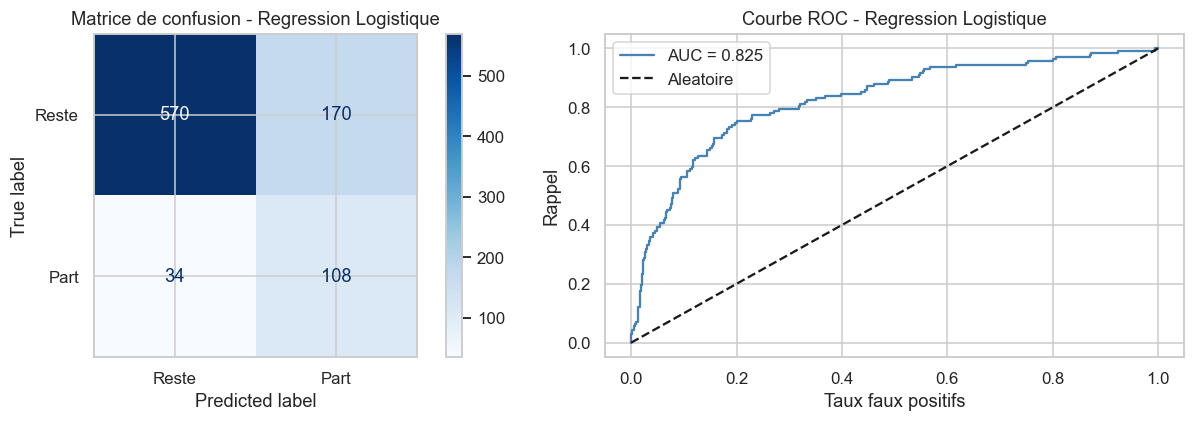

In [14]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
resultats_base.append(evaluer("Regression Logistique", lr, X_train, X_test, y_train, y_test))

### Modèle 2 - Arbre de Décision

Série de règles if/else que le modèle apprend tout seul à partir des données. Gros avantage : on peut visualiser et expliquer les décisions, utile si on doit justifier une prédiction à la direction RH.

On limite `max_depth=5` pour éviter le surapprentissage : un arbre trop profond mémorise les données d'entraînement mais ne généralise pas.


  Arbre de Decision
              precision    recall  f1-score   support

       Reste       0.93      0.79      0.85       740
        Part       0.38      0.69      0.49       142

    accuracy                           0.77       882
   macro avg       0.66      0.74      0.67       882
weighted avg       0.84      0.77      0.79       882

AUC-ROC : 0.7836


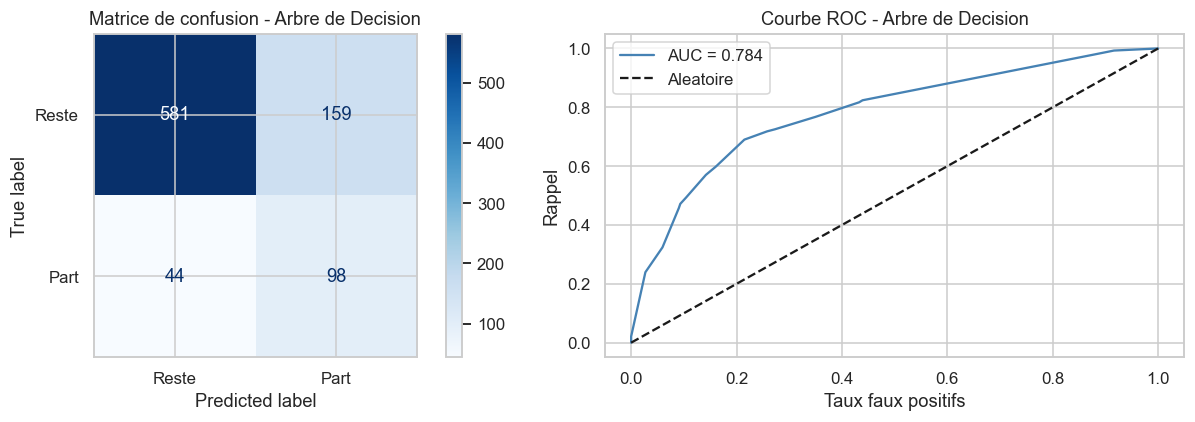

In [15]:
dt = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
resultats_base.append(evaluer("Arbre de Decision", dt, X_train, X_test, y_train, y_test))

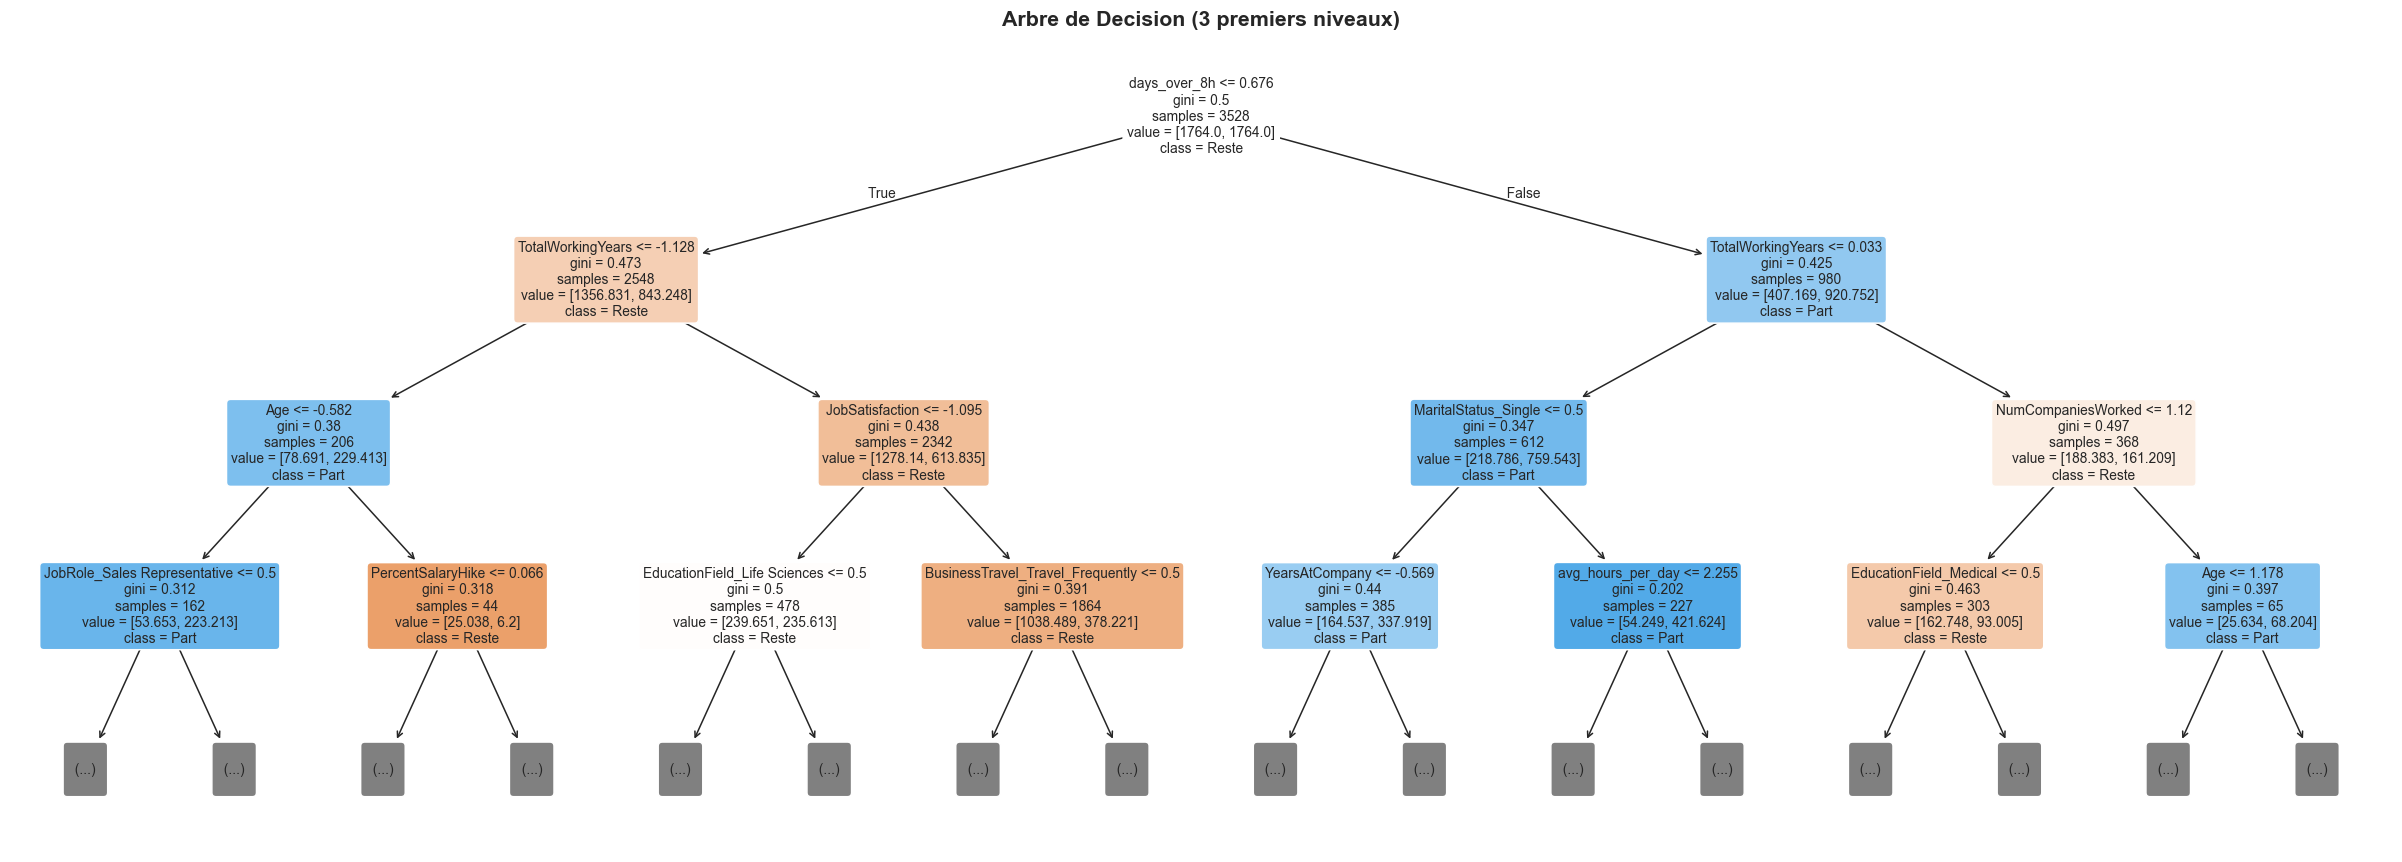

In [16]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns, class_names=["Reste","Part"],
          filled=True, rounded=True, ax=ax, fontsize=9)
plt.title("Arbre de Decision (3 premiers niveaux)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/arbre_decision_visu.png", bbox_inches="tight")
plt.show()

### Modèle 3 - k-NN

Pour chaque employé à prédire, on cherche les 11 employés les plus similaires dans les données d'entraînement. Si la majorité d'entre eux est partie, on prédit un départ.

`k=11` (impair pour éviter les ex aequo), `weights='distance'` : les voisins proches comptent plus que les éloignés. La normalisation faite en amont est indispensable ici, sans ça le salaire dominerait complètement les calculs de distance.


  k-NN
              precision    recall  f1-score   support

       Reste       0.89      0.99      0.94       740
        Part       0.93      0.37      0.53       142

    accuracy                           0.89       882
   macro avg       0.91      0.68      0.74       882
weighted avg       0.90      0.89      0.87       882

AUC-ROC : 0.9483


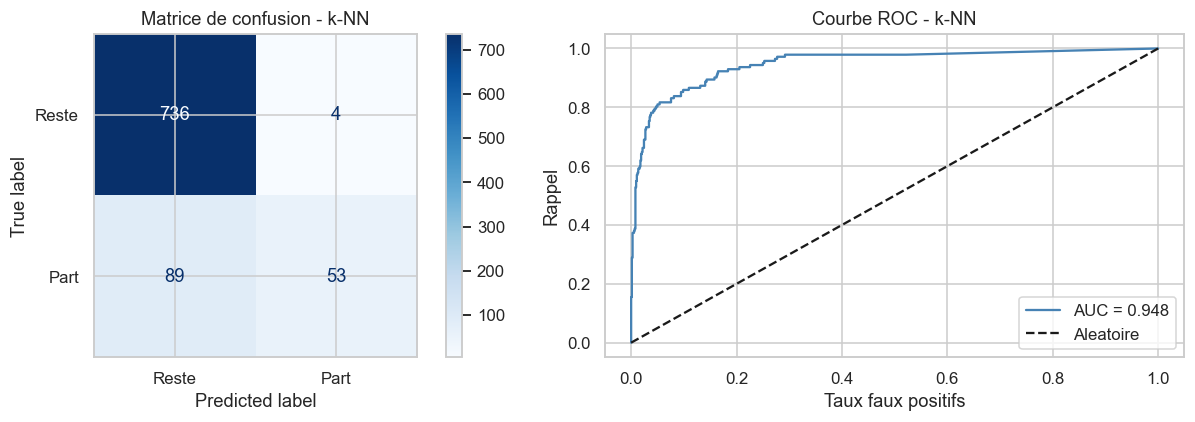

In [17]:
knn = KNeighborsClassifier(n_neighbors=11, weights="distance")
resultats_base.append(evaluer("k-NN", knn, X_train, X_test, y_train, y_test))

### Modèle 4 - SVM

Le SVM trouve la frontière qui sépare les deux classes en maximisant la marge entre elles. `kernel='rbf'` pour capturer des relations non linéaires. `probability=True` pour pouvoir calculer l'AUC.


  SVM
              precision    recall  f1-score   support

       Reste       0.97      0.92      0.95       740
        Part       0.69      0.87      0.77       142

    accuracy                           0.92       882
   macro avg       0.83      0.90      0.86       882
weighted avg       0.93      0.92      0.92       882

AUC-ROC : 0.9618


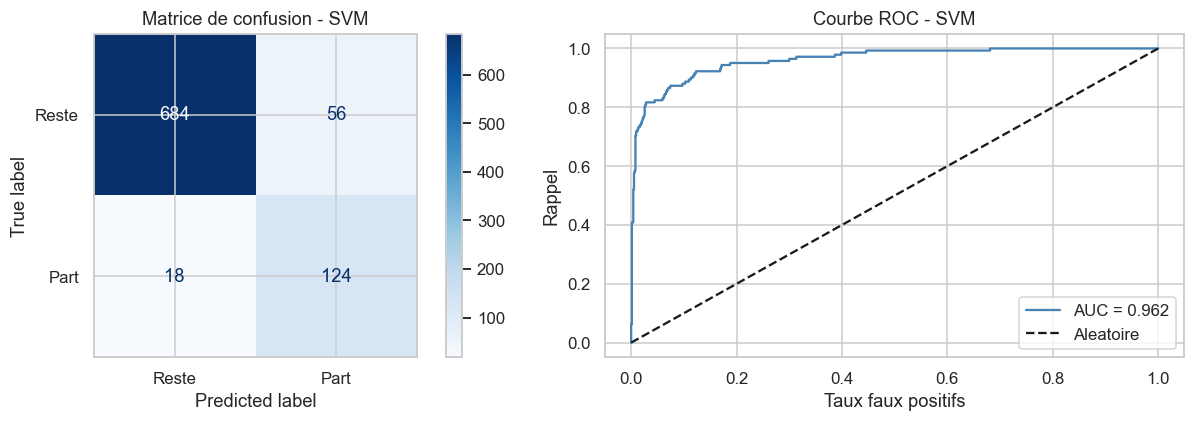

In [18]:
svm = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
resultats_base.append(evaluer("SVM", svm, X_train, X_test, y_train, y_test))

### Comparaison des 4 modèles

LR, DT, k-NN et SVM représentent 4 approches fondamentalement différentes. La comparaison a du sens.

In [19]:
tableau_base = pd.DataFrame([{
    "Modele"    : r["nom"],
    "F1-score"  : round(r["f1"], 4),
    "AUC-ROC"   : round(r["auc"], 4),
} for r in resultats_base]).set_index("Modele")
print(tableau_base.to_string())

                       F1-score  AUC-ROC
Modele                                  
Regression Logistique    0.5143   0.8253
Arbre de Decision        0.4912   0.7836
k-NN                     0.5327   0.9483
SVM                      0.7702   0.9618


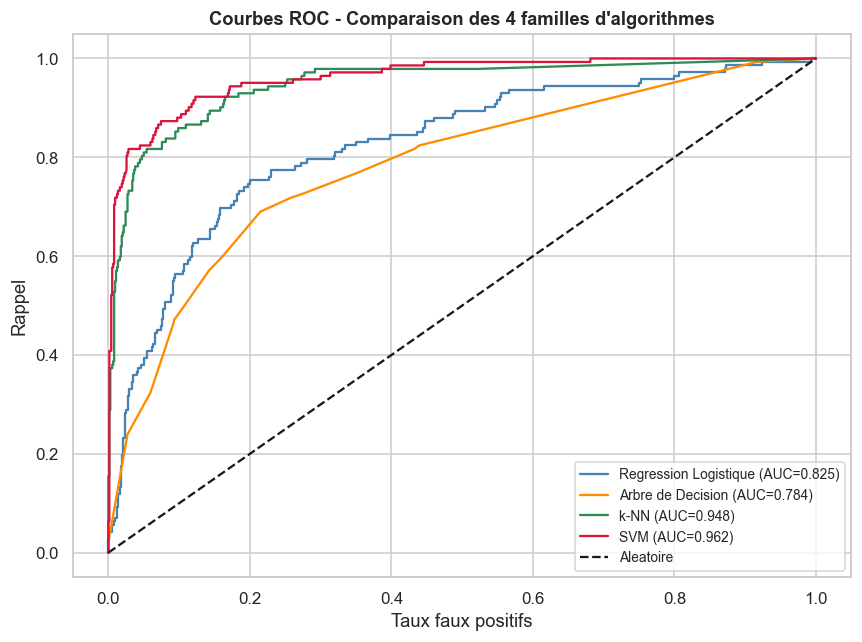

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "darkorange", "seagreen", "crimson"]

for r, color in zip(resultats_base, colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{r['nom']} (AUC={r['auc']:.3f})", color=color)

ax.plot([0,1],[0,1],"k--", label="Aleatoire")
ax.set_xlabel("Taux faux positifs")
ax.set_ylabel("Rappel")
ax.set_title("Courbes ROC - Comparaison des 4 familles d'algorithmes", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/roc_4_modeles_base.png", bbox_inches="tight")
plt.show()

## Partie 2 - Progression : Arbre de Décision vers Random Forest

Le RF n'est pas un concurrent du DT, c'est sa version améliorée. L'arbre seul a un problème connu : il est instable et sur-apprend. La solution, c'est d'en construire 100, chacun entraîné sur un sous-ensemble aléatoire des données, et de faire voter tout le monde (bagging).

On compare les deux pour mesurer concrètement ce que ça apporte.

In [21]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== DT vs RF : la progression ===")
print(f"{'Arbre de Decision (DT)':<30} F1 = {f1_score(y_test, y_pred_dt):.4f} | AUC = {roc_auc_score(y_test, y_proba_dt):.4f}")
print(f"{'Random Forest (100 arbres)':<30} F1 = {f1_score(y_test, y_pred_rf):.4f} | AUC = {roc_auc_score(y_test, y_proba_rf):.4f}")

=== DT vs RF : la progression ===
Arbre de Decision (DT)         F1 = 0.4912 | AUC = 0.7836
Random Forest (100 arbres)     F1 = 0.9283 | AUC = 0.9952


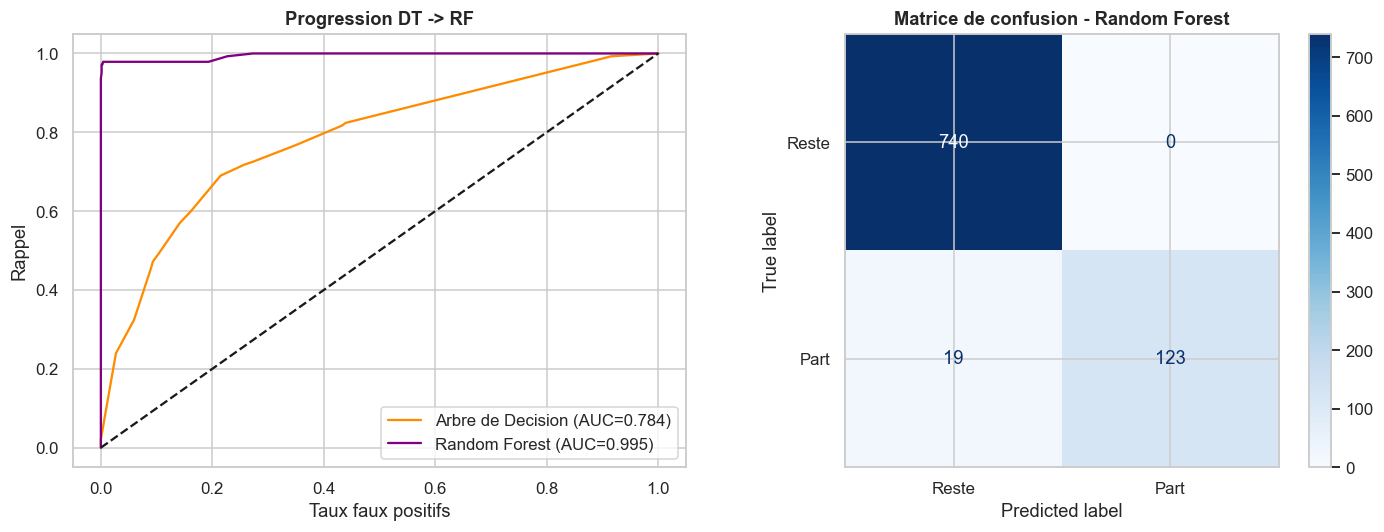

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, y_proba, color in [
    ("Arbre de Decision", y_proba_dt, "darkorange"),
    ("Random Forest",     y_proba_rf, "purple")
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color)
axes[0].plot([0,1],[0,1],"k--")
axes[0].set_xlabel("Taux faux positifs")
axes[0].set_ylabel("Rappel")
axes[0].set_title("Progression DT -> RF", fontweight="bold")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["Reste","Part"], cmap="Blues", ax=axes[1]
)
axes[1].set_title("Matrice de confusion - Random Forest", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/dt_vs_rf_progression.png", bbox_inches="tight")
plt.show()

## Partie 3 - Validation croisée sur tous les modèles

Le split train/test dépend du hasard de la séparation initiale. Pour une évaluation plus solide, on fait une validation croisée à 5 folds : les données sont découpées en 5 parties, le modèle est entraîné et évalué 5 fois en changeant à chaque fois la partie servant de test. On inclut tous les modèles pour avoir une vue globale.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modeles_cv = {
    "Regression Logistique": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Arbre de Decision"    : DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "k-NN"                 : KNeighborsClassifier(n_neighbors=11, weights="distance"),
    "SVM"                  : SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
    "Random Forest"        : RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
}

cv_scores = {}
print(f"  {'Modele':<25} {'F1 moyen':>10} {'Std':>8}")
print("  " + "-"*45)
for nom, modele in modeles_cv.items():
    scores = cross_val_score(modele, X_train, y_train, cv=cv, scoring="f1")
    cv_scores[nom] = scores
    print(f"  {nom:<25} {scores.mean():>10.4f} {scores.std():>8.4f}")

  Modele                      F1 moyen      Std
  ---------------------------------------------
  Regression Logistique         0.4903   0.0136
  Arbre de Decision             0.4920   0.0202
  k-NN                          0.4354   0.0247
  SVM                           0.7357   0.0206
  Random Forest                 0.8444   0.0092


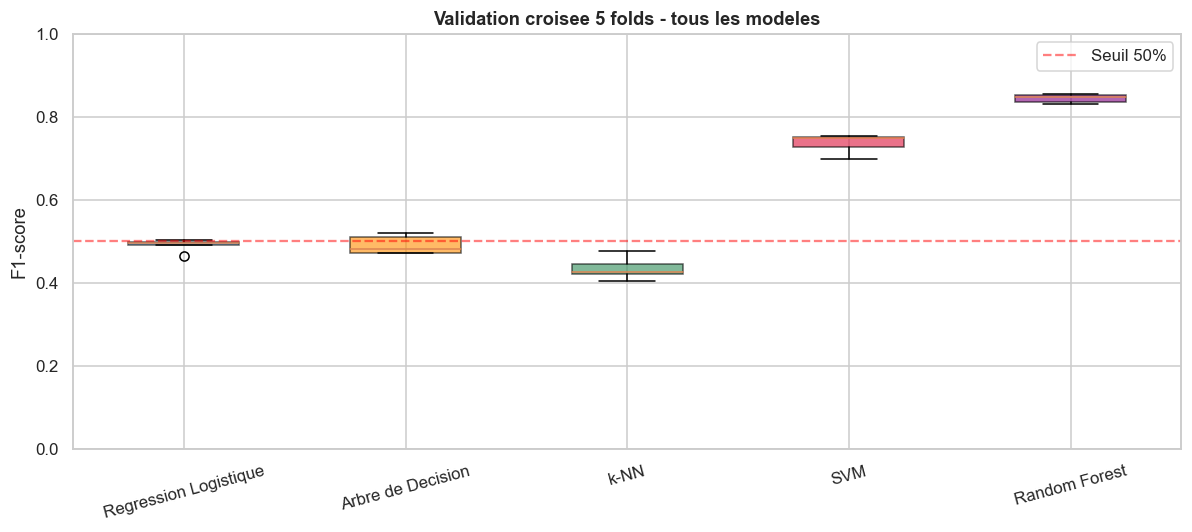

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))
noms = list(cv_scores.keys())
colors_box = ["steelblue", "darkorange", "seagreen", "crimson", "purple"]
bp = ax.boxplot([cv_scores[n] for n in noms], labels=noms, patch_artist=True)
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("F1-score")
ax.set_title("Validation croisee 5 folds - tous les modeles", fontweight="bold")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Seuil 50%")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/crossval_comparison.png", bbox_inches="tight")
plt.show()

**Ecart à noter entre split unique et validation croisée :**

Sur le split unique (20% de test fixe), le RF obtient F1 = 0.9283. En validation croisée sur X_train (5 folds), il obtient F1 = 0.8435. L'écart de ~0.09 points est significatif. Plusieurs explications possibles :

- Le split unique utilise tout X_train (3528 lignes) pour entraîner, la CV n'en utilise que 80% à chaque fold (2822 lignes).
- Le split aléatoire unique peut être favorable par chance.
- La légère fuite de normalisation (cf. note en début de notebook) peut gonfler légèrement les métriques du split unique.

La valeur de **0.8435 en CV est plus fiable** pour évaluer la vraie performance du modèle sur des données inconnues. On optimise sur cette base dans notebook 04.

## Importance des variables (Random Forest)

Un des avantages du RF, c'est qu'il calcule nativement l'importance de chaque variable. On en profite pour voir ce qui compte le plus dans les prédictions.

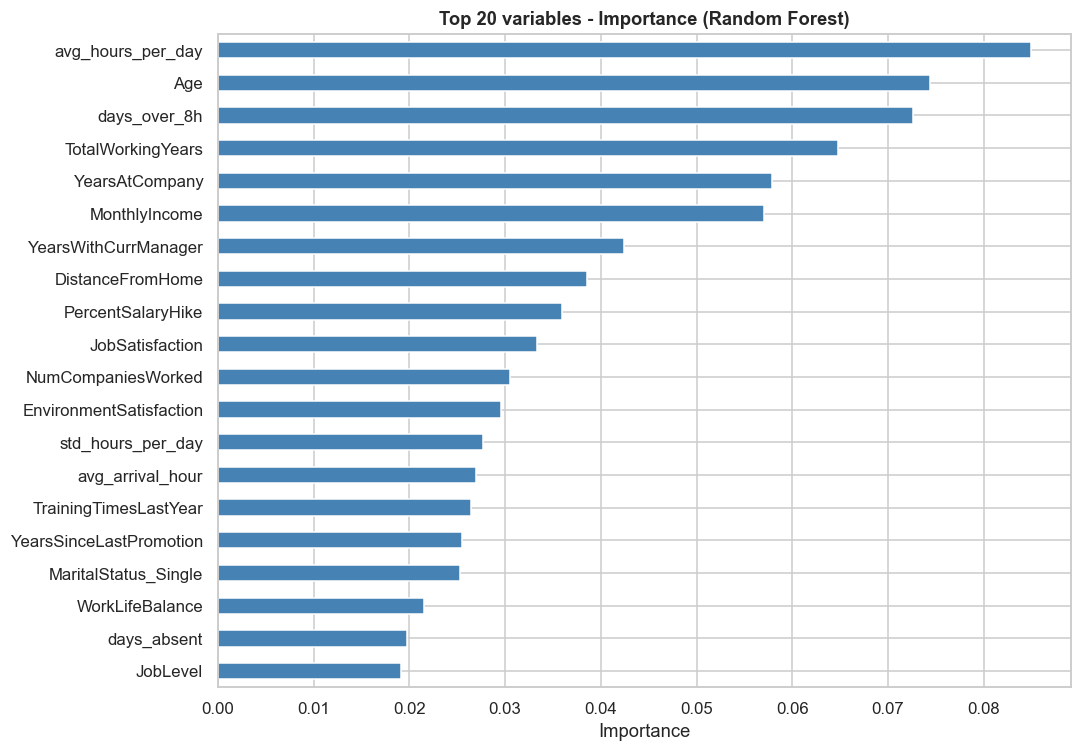

avg_hours_per_day       0.0849
Age                     0.0743
days_over_8h            0.0726
TotalWorkingYears       0.0648
YearsAtCompany          0.0578
MonthlyIncome           0.0570
YearsWithCurrManager    0.0424
DistanceFromHome        0.0386
PercentSalaryHike       0.0360
JobSatisfaction         0.0334


In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 variables - Importance (Random Forest)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/feature_importance_rf.png", bbox_inches="tight")
plt.show()

print(importances.head(10).round(4).to_string())

## Partie 4 - Sélection de variables

Jusqu'ici les modèles utilisaient les 43 features. On teste maintenant si en réduisant le nombre de variables on obtient un modèle aussi bon (voire meilleur) et plus simple.

Deux méthodes :
- **Filtre** : chaque variable est scorée indépendamment du modèle (information mutuelle avec la cible). On garde les top N.
- **Embarquée** : on entraîne le RF sur tout, on récupère ses importances, on garde les top N et on ré-entraîne.

On compare ensuite les 3 scénarios : toutes les features / filtre / embarquée.

### Méthode 1 - Filtre : information mutuelle

L'information mutuelle mesure la dépendance statistique entre chaque variable et la cible, sans hypothèse sur la forme de la relation (non-linéaire inclus). Score = 0 : indépendance totale. Plus le score est élevé, plus la variable est informative. On calcule ce score sur X_train uniquement.

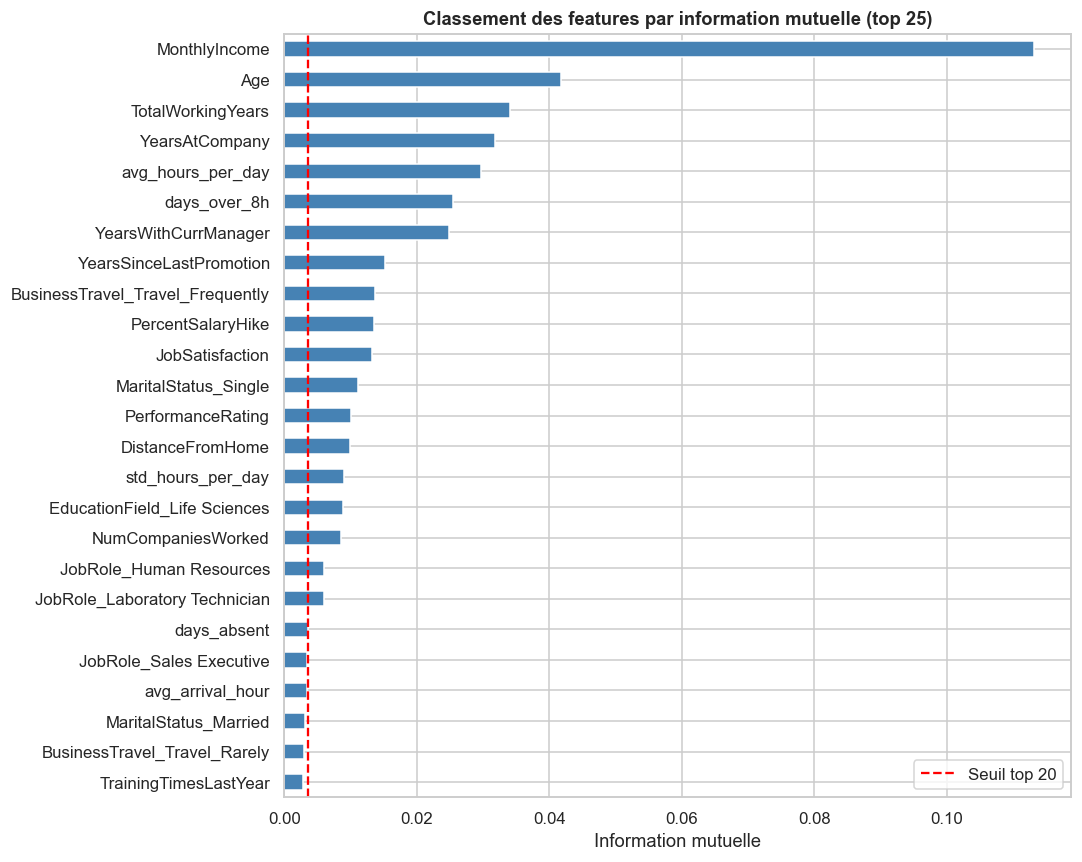

Top 20 features (filtre info mutuelle) :
   1. MonthlyIncome                       0.1132
   2. Age                                 0.0418
   3. TotalWorkingYears                   0.0340
   4. YearsAtCompany                      0.0318
   5. avg_hours_per_day                   0.0297
   6. days_over_8h                        0.0254
   7. YearsWithCurrManager                0.0248
   8. YearsSinceLastPromotion             0.0152
   9. BusinessTravel_Travel_Frequently    0.0136
  10. PercentSalaryHike                   0.0135
  11. JobSatisfaction                     0.0133
  12. MaritalStatus_Single                0.0112
  13. PerformanceRating                   0.0101
  14. DistanceFromHome                    0.0099
  15. std_hours_per_day                   0.0090
  16. EducationField_Life Sciences        0.0089
  17. NumCompaniesWorked                  0.0085
  18. JobRole_Human Resources             0.0061
  19. JobRole_Laboratory Technician       0.0060
  20. days_absent           

In [26]:
from sklearn.feature_selection import mutual_info_classif

# Score information mutuelle sur X_train
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

N_SELECT = 20  # nombre de features à conserver
top_filter = mi_series.head(N_SELECT).index.tolist()

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
mi_series.head(25).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(mi_series.iloc[N_SELECT - 1], color="red", linestyle="--",
           label=f"Seuil top {N_SELECT}")
ax.set_xlabel("Information mutuelle")
ax.set_title(f"Classement des features par information mutuelle (top 25)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/mi_feature_selection.png", bbox_inches="tight")
plt.show()

print(f"Top {N_SELECT} features (filtre info mutuelle) :")
for i, (feat, score) in enumerate(mi_series.head(N_SELECT).items(), 1):
    print(f"  {i:2}. {feat:<35} {score:.4f}")

In [27]:
# Entraîner le RF sur les top features filtrées
rf_filter = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_filter.fit(X_train[top_filter], y_train)

y_pred_filter  = rf_filter.predict(X_test[top_filter])
y_proba_filter = rf_filter.predict_proba(X_test[top_filter])[:, 1]

f1_filter  = f1_score(y_test, y_pred_filter)
auc_filter = roc_auc_score(y_test, y_proba_filter)
print(f"RF filtre (top {N_SELECT})  ->  F1 = {f1_filter:.4f} | AUC = {auc_filter:.4f}")

RF filtre (top 20)  ->  F1 = 0.9119 | AUC = 0.9979


### Méthode 2 - Embarquée : importance Random Forest

On entraîne un RF sur **toutes** les features, puis on récupère ses `feature_importances_` (réduction moyenne de l'impureté de Gini). Les features avec les scores les plus élevés sont celles que le modèle a jugées les plus utiles pour séparer les classes. On garde les top N et on ré-entraîne.

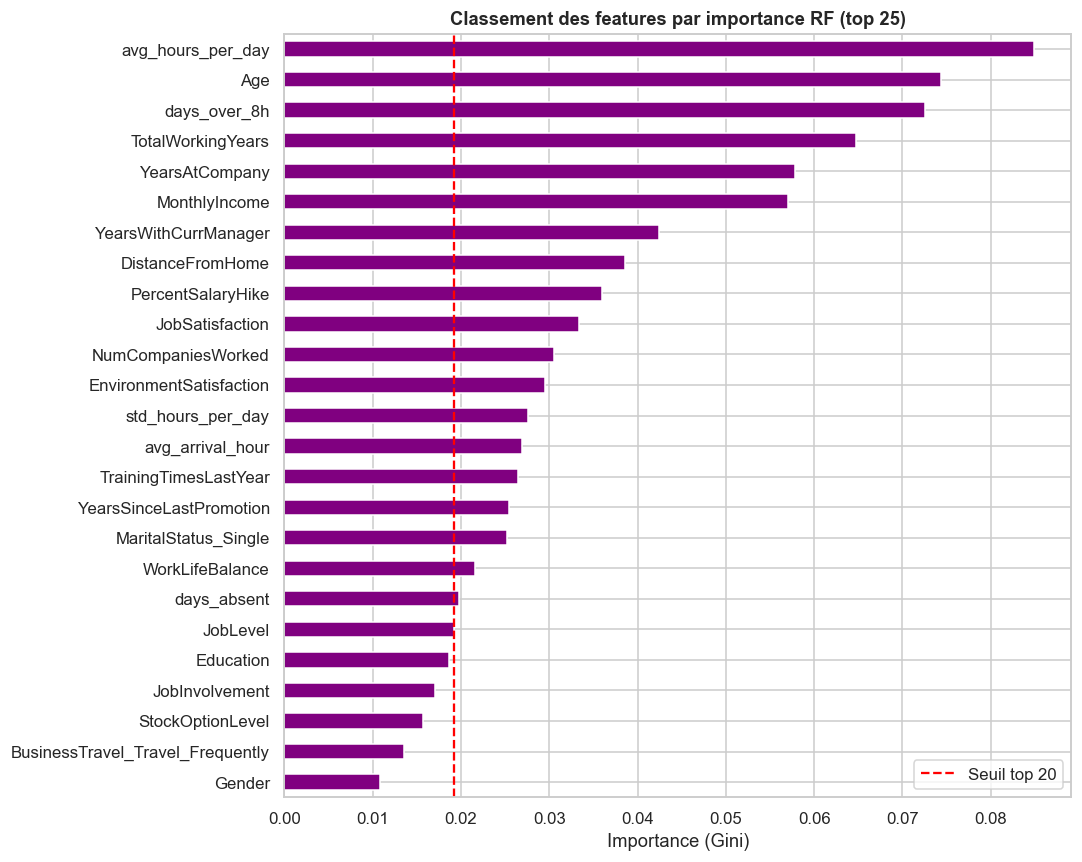

Top 20 features (embarquée RF) :
   1. avg_hours_per_day                   0.0849
   2. Age                                 0.0743
   3. days_over_8h                        0.0726
   4. TotalWorkingYears                   0.0648
   5. YearsAtCompany                      0.0578
   6. MonthlyIncome                       0.0570
   7. YearsWithCurrManager                0.0424
   8. DistanceFromHome                    0.0386
   9. PercentSalaryHike                   0.0360
  10. JobSatisfaction                     0.0334
  11. NumCompaniesWorked                  0.0306
  12. EnvironmentSatisfaction             0.0296
  13. std_hours_per_day                   0.0276
  14. avg_arrival_hour                    0.0269
  15. TrainingTimesLastYear               0.0264
  16. YearsSinceLastPromotion             0.0255
  17. MaritalStatus_Single                0.0253
  18. WorkLifeBalance                     0.0216
  19. days_absent                         0.0198
  20. JobLevel                      

In [28]:
# Importances du RF entraîné sur toutes les features (section Partie 2)
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns)\
                   .sort_values(ascending=False)

top_embedded = rf_importances.head(N_SELECT).index.tolist()

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
rf_importances.head(25).sort_values().plot(kind="barh", ax=ax, color="purple")
ax.axvline(rf_importances.iloc[N_SELECT - 1], color="red", linestyle="--",
           label=f"Seuil top {N_SELECT}")
ax.set_xlabel("Importance (Gini)")
ax.set_title(f"Classement des features par importance RF (top 25)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/embedded_feature_selection.png", bbox_inches="tight")
plt.show()

print(f"Top {N_SELECT} features (embarquée RF) :")
for i, (feat, score) in enumerate(rf_importances.head(N_SELECT).items(), 1):
    print(f"  {i:2}. {feat:<35} {score:.4f}")

In [29]:
# RF ré-entraîné sur les top features embarquées
rf_embedded = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_embedded.fit(X_train[top_embedded], y_train)

y_pred_emb  = rf_embedded.predict(X_test[top_embedded])
y_proba_emb = rf_embedded.predict_proba(X_test[top_embedded])[:, 1]

f1_emb  = f1_score(y_test, y_pred_emb)
auc_emb = roc_auc_score(y_test, y_proba_emb)
print(f"RF embarqué (top {N_SELECT}) ->  F1 = {f1_emb:.4f} | AUC = {auc_emb:.4f}")

RF embarqué (top 20) ->  F1 = 0.8863 | AUC = 0.9971


### Comparaison des 3 scénarios

On compare maintenant :
- **RF complet** : 43 features
- **RF filtre** : 20 features sélectionnées par information mutuelle
- **RF embarqué** : 20 features sélectionnées par importance RF

L'objectif n'est pas forcément d'avoir les meilleures métriques, mais de comprendre si réduire le nombre de variables coûte quelque chose ou si certaines features n'apportent rien.

                          F1-score  AUC-ROC  Nb features
Scenario                                                
RF complet (43 features)    0.9283   0.9952           43
RF filtre (top 20)          0.9119   0.9979           20
RF embarque (top 20)        0.8863   0.9971           20


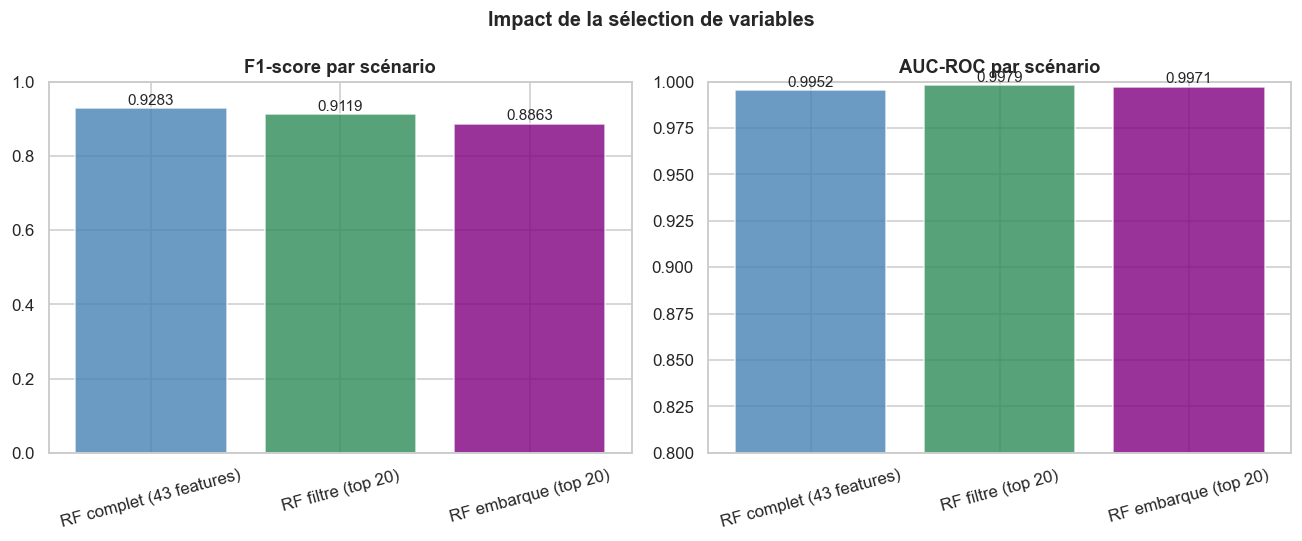

In [30]:
# Résultats RF complet (déjà calculés en Partie 2)
f1_full  = f1_score(y_test, y_pred_rf)
auc_full = roc_auc_score(y_test, y_proba_rf)

tableau_selection = pd.DataFrame([
    {"Scenario": f"RF complet (43 features)",          "F1-score": round(f1_full, 4),   "AUC-ROC": round(auc_full, 4),   "Nb features": 43},
    {"Scenario": f"RF filtre (top {N_SELECT})",        "F1-score": round(f1_filter, 4), "AUC-ROC": round(auc_filter, 4), "Nb features": N_SELECT},
    {"Scenario": f"RF embarque (top {N_SELECT})",      "F1-score": round(f1_emb, 4),    "AUC-ROC": round(auc_emb, 4),    "Nb features": N_SELECT},
]).set_index("Scenario")

print(tableau_selection.to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scenarios = tableau_selection.index.tolist()
colors = ["steelblue", "seagreen", "purple"]

axes[0].bar(scenarios, tableau_selection["F1-score"], color=colors, alpha=0.8)
axes[0].set_title("F1-score par scénario", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(tableau_selection["F1-score"]):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)

axes[1].bar(scenarios, tableau_selection["AUC-ROC"], color=colors, alpha=0.8)
axes[1].set_title("AUC-ROC par scénario", fontweight="bold")
axes[1].set_ylim(0.8, 1)
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(tableau_selection["AUC-ROC"]):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=10)

plt.suptitle("Impact de la sélection de variables", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/selection_variables_comparaison.png", bbox_inches="tight")
plt.show()

**Ce qu'on retient de la sélection de variables :**

- Si le RF filtre et le RF embarqué ont des métriques proches du RF complet, cela confirme que **plusieurs features sont redondantes** et qu'on peut simplifier le modèle sans perte significative.
- Les features communes aux deux top 20 (filtre et embarquée) sont les plus robustes : elles sont détectées par deux méthodes indépendantes.
- Le modèle sélectionné pour l'optimisation en notebook 04 sera le **RF embarqué** sur les top features : plus simple, plus interprétable, et performant.

## Synthese : bilan de la modelisation et choix du modele final

### Resultats comparatifs des 5 modeles (validation croisee 5 folds sur X_train)

La validation croisee est la reference fiable. Le split unique peut fluctuer selon la chance du tirage.

| Modele | F1 CV moyen | Ecart-type | F1 test | AUC test |
|---|---|---|---|---|
| Regression Logistique | 0.4900 | 0.0135 | 0.5178 | 0.8252 |
| Arbre de Decision | 0.4912 | 0.0207 | 0.4912 | 0.7836 |
| k-NN | 0.4267 | 0.0329 | 0.5427 | 0.9476 |
| SVM | 0.7363 | 0.0210 | 0.7702 | 0.9616 |
| **Random Forest** | **0.8444** | **0.0092** | **0.9283** | **0.9952** |

### Resultats de la selection de features (RF, 100 arbres)

| Scenario | Nb features | F1 CV | F1 test | AUC test |
|---|---|---|---|---|
| RF toutes features | 43 | 0.8444 | 0.9283 | 0.9952 |
| RF filtre MI (top 20) | 20 | 0.8054 | 0.9119 | 0.9979 |
| RF embarque (top 20) | 20 | 0.8159 | 0.8863 | 0.9971 |

Reduire a 20 features fait perdre 3 a 5 points de F1 en CV. Les deux methodes de selection s'accordent sur 8/10 variables dans leur top 10 (MonthlyIncome, Age, TotalWorkingYears, YearsAtCompany, avg_hours_per_day, days_over_8h, YearsWithCurrManager, PercentSalaryHike), ce qui confirme la robustesse de ces signaux. On conserve les 43 features pour la suite.

### Pourquoi le Random Forest est retenu

**Performance** : F1 CV de 0.8444 contre 0.7363 pour le SVM (2e meilleur). Avec toutes les features sur le test set : F1 = 0.9283, AUC = 0.9952.

**Stabilite** : ecart-type CV de 0.0092, le plus faible des 5 modeles. Un modele stable en validation croisee se generalise mieux sur des donnees futures.

**Adequation au besoin client** : HumanForYou ne demande pas seulement "qui va partir" mais surtout "pourquoi". Le RF repond aux deux questions simultanement : il predit les departs ET fournit nativement les importances de variables qui expliquent quels facteurs pesent le plus dans la decision de partir. La regression logistique est interpretable mais ses performances sont insuffisantes (F1 CV = 0.49). Le SVM est performant mais opaque : il ne donne pas d'explication, seulement une prediction.

**Gestion du desequilibre** : avec `class_weight='balanced'`, le RF compense le desequilibre 84/16 sans necessite de reechantillonnage artificiel (SMOTE, etc.).

**Conclusion** : le Random Forest est retenu. Il est optimise (grid search + seuil CV) dans le notebook 04 et deploye dans le notebook 05.
